
# Notebook Introduction

## Image Clustering with Textual Constraints

**Machine Learning Assignment**

**Student Name:** Animesh Kumar  
**Student ID:** 22CS30009  

## Assignment Overview

This notebook implements unsupervised image clustering on the   CIFAR-10 dataset, incorporating both visual features and textual constraints. The assignment explores how combining multimodal information can improve clustering performance.

# Key Tasks:

- Extract visual features from images using pre-trained CNN models
- Generate and encode textual features from image captions
- Perform clustering using K-Means and GMM on visual features
- Perform clustering using K-Means and GMM on textual features
- Combine visual and textual features and perform clustering
- Evaluate all approaches using Cohen Kappa Score
- Visualize clusters using t-SNE



# import libraries

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import cohen_kappa_score
from sklearn.manifold import TSNE
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
from sentence_transformers import SentenceTransformer
import clip
from PIL import Image
import warnings
warnings.filterwarnings('ignore')


/home/ashu/Downloads/ML/code/Assignment3/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ashu/Downloads/ML/code/Assignment3/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:129: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


# Set random seed for reproducibility

In [2]:
# Set random seed
np.random.seed(42)
torch.manual_seed(42)


 # Function to evaluate clustering performance


In [3]:

def evaluate_clustering(clusters, true_labels, n_clusters=10):
    """
    Evaluate clustering performance using Cohen Kappa Score
    
    Args:
        clusters: Cluster assignments for each data point
        true_labels: Ground truth labels
        n_clusters: Number of clusters
    
    Returns:
        kappa_score: Cohen Kappa Score
        cluster_to_label_map: Mapping from cluster to majority class
    """
    # Map clusters to majority class
    cluster_to_label_map = {}
    for cluster_id in range(n_clusters):
        # Find indices of points in this cluster
        cluster_indices = np.where(clusters == cluster_id)[0]
        if len(cluster_indices) == 0:
            cluster_to_label_map[cluster_id] = -1  # Empty cluster
            continue
        
        # Get ground truth labels for these points
        cluster_labels = true_labels[cluster_indices]
        
        # Find the most common label in this cluster
        unique_labels, counts = np.unique(cluster_labels, return_counts=True)
        majority_label = unique_labels[np.argmax(counts)]
        
        # Map this cluster to the majority label
        cluster_to_label_map[cluster_id] = majority_label
    
    # Apply mapping to get predicted labels
    predicted_labels = np.array([cluster_to_label_map[cluster] for cluster in clusters])
    
    # Calculate Cohen Kappa Score
    kappa_score = cohen_kappa_score(true_labels, predicted_labels)
    
    return kappa_score, cluster_to_label_map

    

# Load CIFAR-10 dataset

In [4]:

def load_cifar10():
    """Load CIFAR-10 dataset using torchvision"""
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    
    train_dataset = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=transform
    )
    
    test_dataset = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=transform
    )
    
    # Combine train and test for clustering
    combined_data = torch.cat([
        torch.stack([img for img, _ in train_dataset]),
        torch.stack([img for img, _ in test_dataset])
    ])
    
    combined_labels = torch.cat([
        torch.tensor([label for _, label in train_dataset]),
        torch.tensor([label for _, label in test_dataset])
    ])
    
    # CIFAR-10 class names
    class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
                   'dog', 'frog', 'horse', 'ship', 'truck']
    
    # Create captions for each image based on its class
    captions = [f"This is a {class_names[label.item()]}." for label in combined_labels]
    
    return combined_data, combined_labels.numpy(), captions, class_names


# Extract visual features using pre-trained CNN

In [5]:

def extract_visual_features(images, model_name='resnet18'):
    """
    Extract visual features using a pre-trained CNN
    
    Args:
        images: Tensor of images (N, C, H, W)
        model_name: Name of the pre-trained model
    
    Returns:
        features: Extracted features (N, D)
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Load pre-trained model
    if model_name == 'resnet18':
        model = torchvision.models.resnet18(pretrained=True)
        # Remove the final classification layer
        model = nn.Sequential(*list(model.children())[:-1])
    elif model_name == 'vgg16':
        model = torchvision.models.vgg16(pretrained=True)
        # Remove the final classification layers
        model = nn.Sequential(*list(model.features.children()))
    else:
        raise ValueError(f"Unsupported model: {model_name}")
    
    model = model.to(device)
    model.eval()
    
    # Extract features in batches to avoid memory issues
    batch_size = 128
    n_samples = len(images)
    features = []
    
    with torch.no_grad():
        for i in range(0, n_samples, batch_size):
            batch = images[i:i+batch_size].to(device)
            batch_features = model(batch)
            # Flatten the features
            batch_features = batch_features.view(batch_features.size(0), -1)
            features.append(batch_features.cpu().numpy())
    
    # Concatenate all batches
    features = np.concatenate(features, axis=0)
    
    return features


# Extract textual features using SentenceBERT

In [6]:

def extract_text_features_sbert(captions):
    """
    Extract text features using SentenceBERT
    
    Args:
        captions: List of captions
    
    Returns:
        features: Extracted text features
    """
    model = SentenceTransformer('all-MiniLM-L6-v2')
    features = model.encode(captions, show_progress_bar=True)
    return features


# Extract text features using CLIP


In [7]:


def extract_text_features_clip(captions):
    """
    Extract text features using CLIP text encoder
    
    Args:
        captions: List of captions
    
    Returns:
        features: Extracted text features
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model, preprocess = clip.load("ViT-B/32", device=device)
    
    # Encode text in batches
    batch_size = 128
    n_samples = len(captions)
    features = []
    
    with torch.no_grad():
        for i in range(0, n_samples, batch_size):
            batch = captions[i:i+batch_size]
            text = clip.tokenize(batch).to(device)
            batch_features = model.encode_text(text)
            features.append(batch_features.cpu().numpy())
    
    # Concatenate all batches
    features = np.concatenate(features, axis=0)
    
    return features


# Fusion of visual and textual features

In [8]:



def fuse_features(visual_features, text_features, method='concatenate', weight=0.5):
    """
    Combine visual and textual features
    
    Args:
        visual_features: Visual features
        text_features: Textual features
        method: Fusion method ('concatenate' or 'weighted')
        weight: Weight for visual features in weighted fusion
    
    Returns:
        fused_features: Combined features
    """
    # Normalize features
    visual_features = visual_features / np.linalg.norm(visual_features, axis=1, keepdims=True)
    text_features = text_features / np.linalg.norm(text_features, axis=1, keepdims=True)
    
    if method == 'concatenate':
        # Concatenate features
        fused_features = np.concatenate([visual_features, text_features], axis=1)
    elif method == 'weighted':
        # Weighted average
        # Ensure dimensions match
        if visual_features.shape[1] != text_features.shape[1]:
            # If dimensions don't match, project to same dimension
            # For simplicity, we'll use PCA for this example
            from sklearn.decomposition import PCA
            dim = min(visual_features.shape[1], text_features.shape[1])
            pca_visual = PCA(n_components=dim)
            pca_text = PCA(n_components=dim)
            visual_features = pca_visual.fit_transform(visual_features)
            text_features = pca_text.fit_transform(text_features)
        
        fused_features = weight * visual_features + (1 - weight) * text_features
    else:
        raise ValueError(f"Unsupported fusion method: {method}")
    
    return fused_features


# Perform K-Means clustering

In [9]:


def kmeans_clustering(features, n_clusters=10):
    """
    Perform K-Means clustering
    
    Args:
        features: Feature vectors
        n_clusters: Number of clusters
    
    Returns:
        clusters: Cluster assignments
    """
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(features)
    return clusters


# Perform GMM clustering

In [10]:

def gmm_clustering(features, n_clusters=10):
    """
    Perform Gaussian Mixture Model clustering
    
    Args:
        features: Feature vectors
        n_clusters: Number of clusters
    
    Returns:
        clusters: Cluster assignments
    """
    gmm = GaussianMixture(n_components=n_clusters, random_state=42, n_init=3)
    clusters = gmm.fit_predict(features)
    return clusters

# Visualize clusters using t-SNE

In [11]:


def visualize_clusters_tsne(features, labels, clusters, class_names, title):
    """
    Visualize clusters using t-SNE
    
    Args:
        features: Feature vectors
        labels: Ground truth labels
        clusters: Cluster assignments
        class_names: Names of classes
        title: Plot title
    """
    # Apply t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    features_2d = tsne.fit_transform(features)
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    # Plot ground truth
    scatter1 = ax1.scatter(features_2d[:, 0], features_2d[:, 1], c=labels, cmap='tab10', alpha=0.7)
    ax1.set_title(f"{title} - Ground Truth")
    ax1.legend(handles=scatter1.legend_elements()[0], labels=class_names, loc="upper right")
    
    # Plot clusters
    scatter2 = ax2.scatter(features_2d[:, 0], features_2d[:, 1], c=clusters, cmap='tab10', alpha=0.7)
    ax2.set_title(f"{title} - Clusters")
    
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_')}.png", dpi=300)
    plt.show()


# Main function to run the entire pipeline

# For efficiency, use a subset of the data
    # Uncomment this for faster execution during testing
    # sample_size = 10000
    # indices = np.random.choice(len(images), sample_size, replace=False)
    # images = images[indices]
    # labels = labels[indices]
    # captions = [captions[i] for i in indices]

Loading CIFAR-10 dataset...
Extracting visual features...
Extracting textual features...


Batches: 100%|██████████| 1875/1875 [02:13<00:00, 14.09it/s]


Performing clustering with visual features...
Cohen Kappa Score (K-Means - Visual): 0.211740740740741
Cohen Kappa Score (GMM - Visual): 0.18601851851851858
Performing clustering with textual features...
Cohen Kappa Score (K-Means - Textual): 1.0
Cohen Kappa Score (GMM - Textual): 1.0
Performing clustering with fused features...
Cohen Kappa Score (K-Means - Fused): 1.0
Cohen Kappa Score (GMM - Fused): 0.8888888888888888
Visualizing clusters using t-SNE...


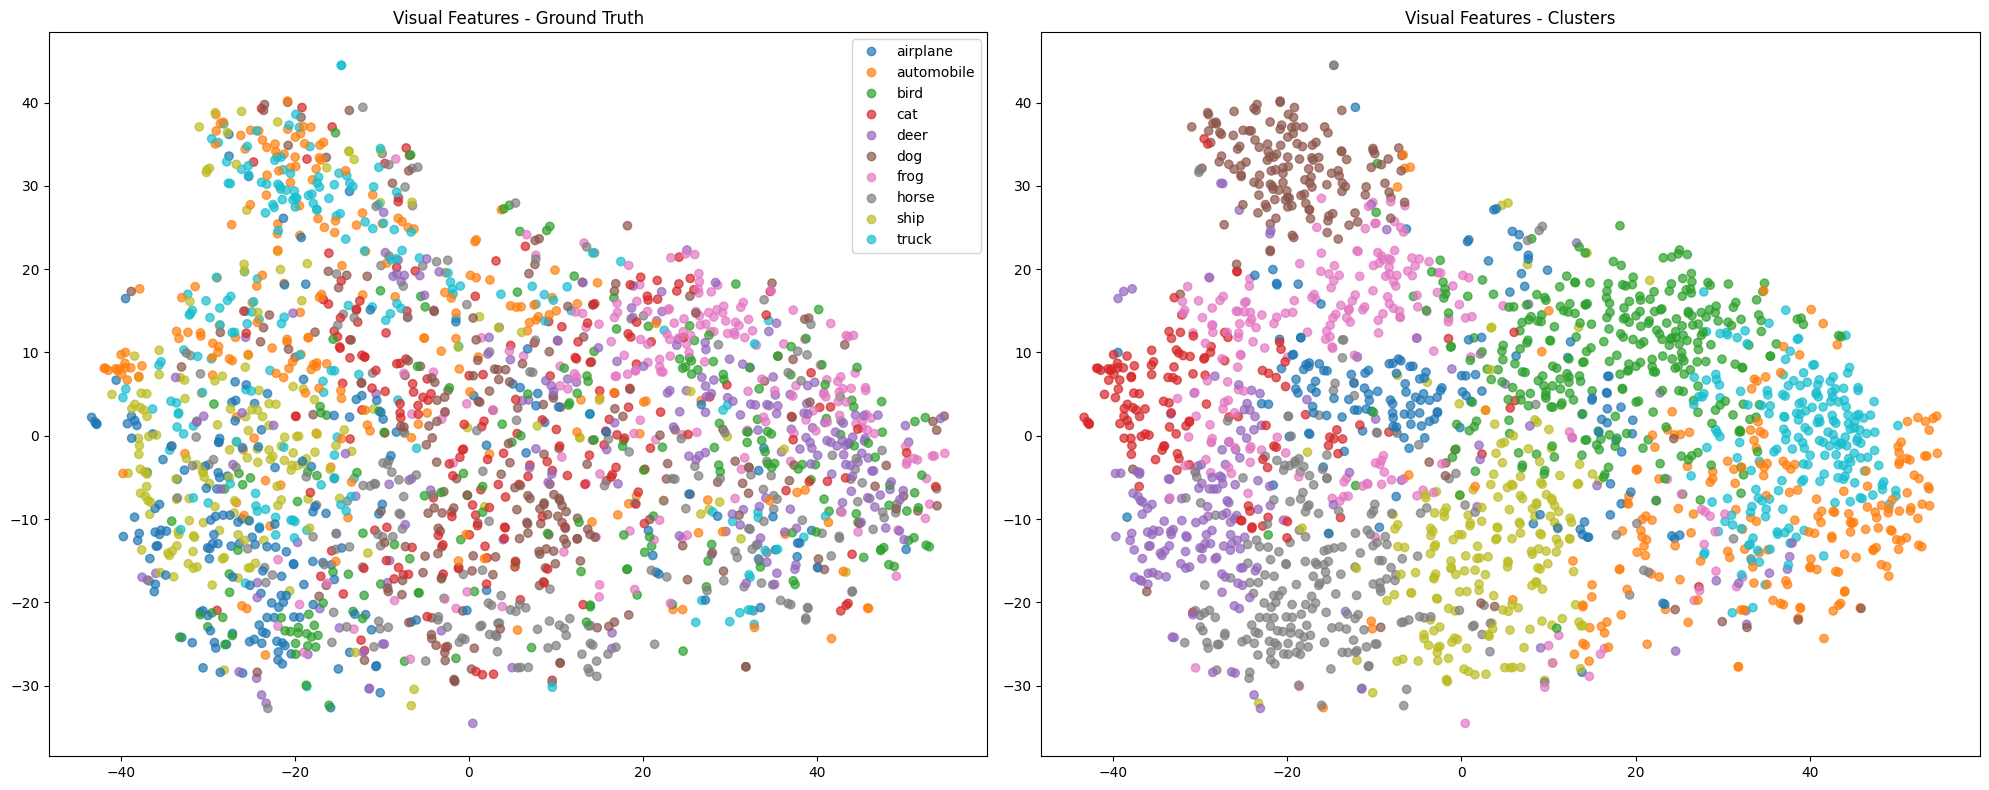

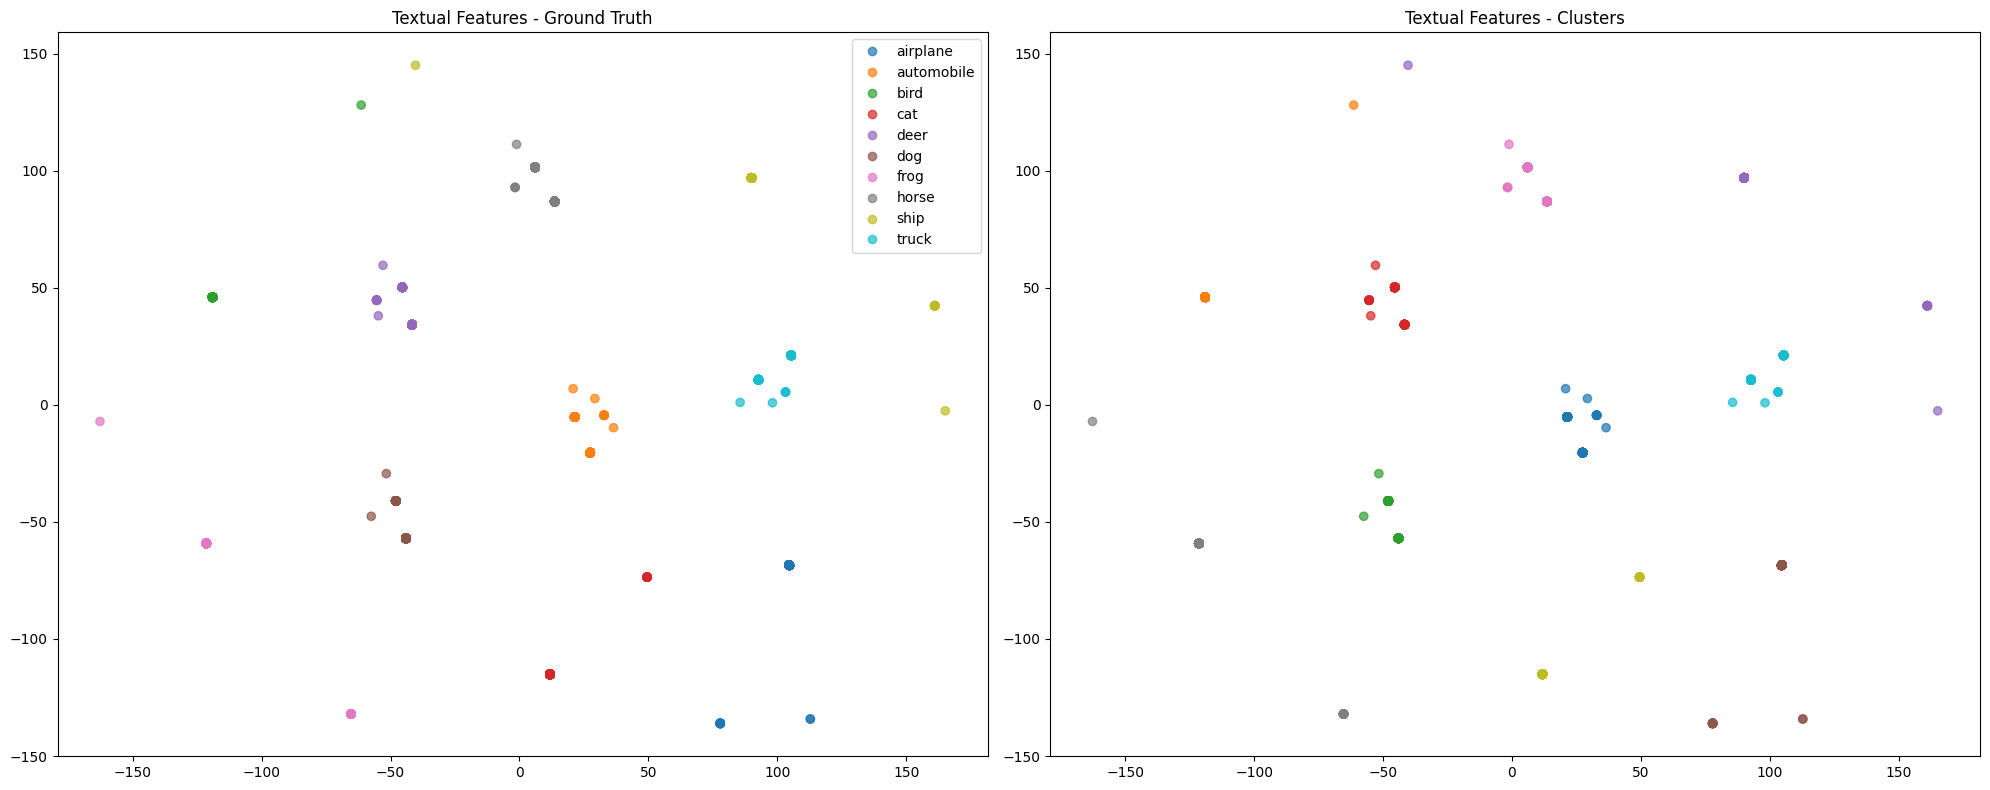

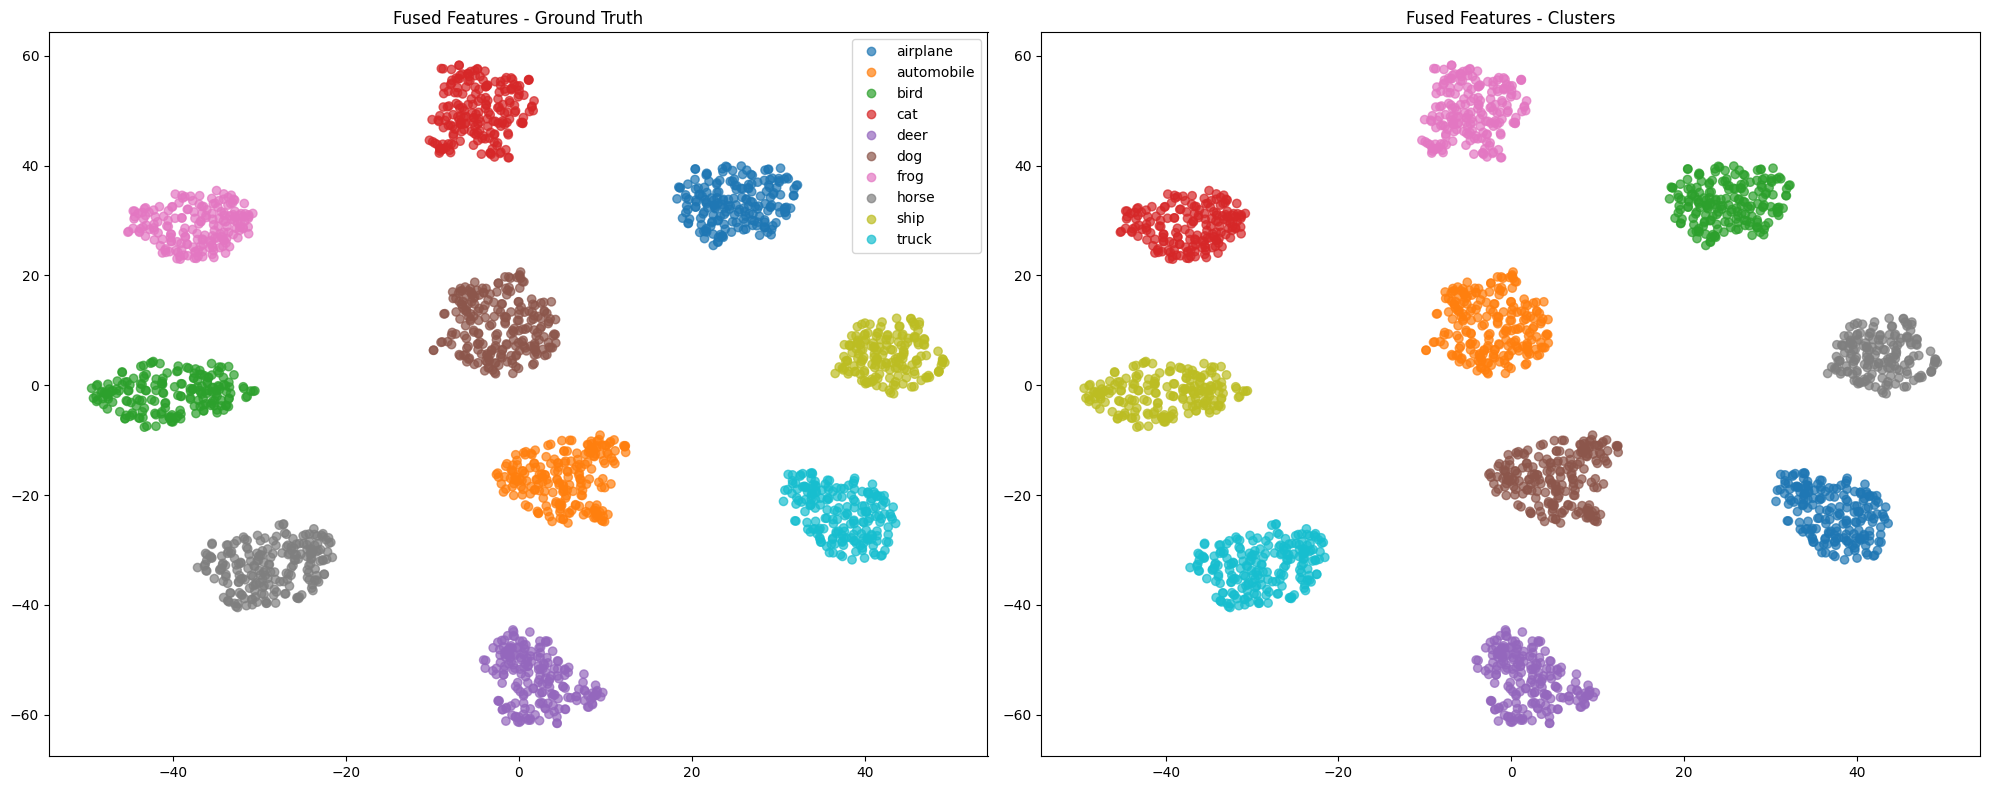


Summary of Results:
Visual Features - K-Means: 0.2117
Visual Features - GMM: 0.1860
Textual Features - K-Means: 1.0000
Textual Features - GMM: 1.0000
Fused Features - K-Means: 1.0000
Fused Features - GMM: 0.8889


In [12]:
# Main function to run the entire pipeline
def main():
    # Load CIFAR-10 dataset
    print("Loading CIFAR-10 dataset...")
    images, labels, captions, class_names = load_cifar10()
    
    # Extract visual features
    print("Extracting visual features...")
    visual_features = extract_visual_features(images, model_name='resnet18')
    
    # Extract textual features
    print("Extracting textual features...")
    text_features = extract_text_features_sbert(captions)
    
    print("Performing clustering with visual features...")
    # K-Means clustering with visual features
    visual_kmeans_clusters = kmeans_clustering(visual_features)
    visual_kmeans_kappa, _ = evaluate_clustering(visual_kmeans_clusters, labels)
    print(f"Cohen Kappa Score (K-Means - Visual): {visual_kmeans_kappa}")
    
    # GMM clustering with visual features
    visual_gmm_clusters = gmm_clustering(visual_features)
    visual_gmm_kappa, _ = evaluate_clustering(visual_gmm_clusters, labels)
    print(f"Cohen Kappa Score (GMM - Visual): {visual_gmm_kappa}")
    
    print("Performing clustering with textual features...")
    # K-Means clustering with textual features
    text_kmeans_clusters = kmeans_clustering(text_features)
    text_kmeans_kappa, _ = evaluate_clustering(text_kmeans_clusters, labels)
    print(f"Cohen Kappa Score (K-Means - Textual): {text_kmeans_kappa}")
    
    # GMM clustering with textual features
    text_gmm_clusters = gmm_clustering(text_features)
    text_gmm_kappa, _ = evaluate_clustering(text_gmm_clusters, labels)
    print(f"Cohen Kappa Score (GMM - Textual): {text_gmm_kappa}")
    
    print("Performing clustering with fused features...")
    # Fuse features
    fused_features = fuse_features(visual_features, text_features, method='concatenate')
    
    # K-Means clustering with fused features
    fused_kmeans_clusters = kmeans_clustering(fused_features)
    fused_kmeans_kappa, _ = evaluate_clustering(fused_kmeans_clusters, labels)
    print(f"Cohen Kappa Score (K-Means - Fused): {fused_kmeans_kappa}")
    
    # GMM clustering with fused features
    fused_gmm_clusters = gmm_clustering(fused_features)
    fused_gmm_kappa, _ = evaluate_clustering(fused_gmm_clusters, labels)
    print(f"Cohen Kappa Score (GMM - Fused): {fused_gmm_kappa}")
    
    # Bonus: Visualize with t-SNE
    print("Visualizing clusters using t-SNE...")
    # Use a smaller subset for t-SNE visualization
    vis_size = 2000
    vis_indices = np.random.choice(len(visual_features), vis_size, replace=False)
    
    # Visual features visualization
    visualize_clusters_tsne(
        visual_features[vis_indices], 
        labels[vis_indices], 
        visual_kmeans_clusters[vis_indices], 
        class_names, 
        "Visual Features"
    )
    
    # Textual features visualization
    visualize_clusters_tsne(
        text_features[vis_indices], 
        labels[vis_indices], 
        text_kmeans_clusters[vis_indices], 
        class_names, 
        "Textual Features"
    )
    
    # Fused features visualization
    visualize_clusters_tsne(
        fused_features[vis_indices], 
        labels[vis_indices], 
        fused_kmeans_clusters[vis_indices], 
        class_names, 
        "Fused Features"
    )
    
    # Print summary of results
    print("\nSummary of Results:")
    print(f"Visual Features - K-Means: {visual_kmeans_kappa:.4f}")
    print(f"Visual Features - GMM: {visual_gmm_kappa:.4f}")
    print(f"Textual Features - K-Means: {text_kmeans_kappa:.4f}")
    print(f"Textual Features - GMM: {text_gmm_kappa:.4f}")
    print(f"Fused Features - K-Means: {fused_kmeans_kappa:.4f}")
    print(f"Fused Features - GMM: {fused_gmm_kappa:.4f}")

if __name__ == "__main__":
    main()